In [6]:
# ------------------------------
# 1. Import Libraries
# ------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

In [7]:
# ------------------------------
# 2. Load and Explore Dataset
# ------------------------------
df = pd.read_csv("heart.csv")

print("First 10 rows of dataset:\n", df.head(10))

# Features and Target
X = df.drop("target", axis=1)
y = df["target"]

feature_names = X.columns
target_names = ["No Disease", "Disease"]

First 10 rows of dataset:
    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   
5   57    1   0       140   192    0        1      148      0      0.4      1   
6   56    0   1       140   294    0        0      153      0      1.3      1   
7   44    1   1       120   263    0        1      173      0      0.0      2   
8   52    1   2       172   199    1        1      162      0      0.5      2   
9   57    1   2       150   168    0        1      174      0      1.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2    

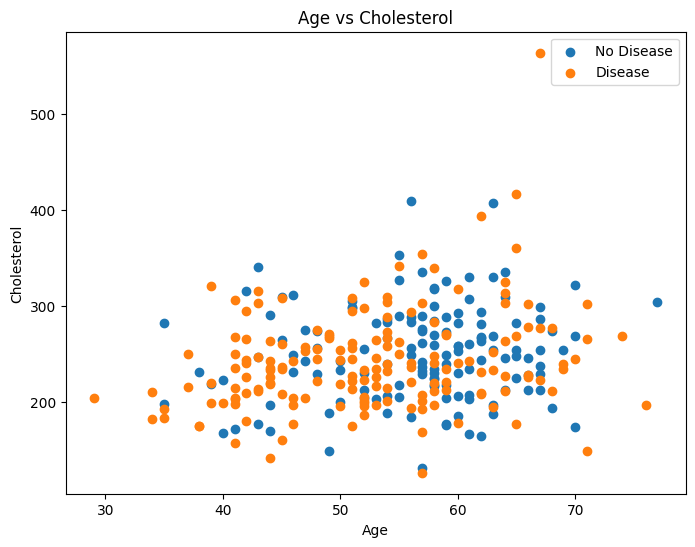

In [8]:
# ------------------------------
# 3. Data Visualization
# ------------------------------

# Age vs Cholesterol
plt.figure(figsize=(8,6))

for t in np.unique(y):
    plt.scatter(df[df['target']==t]['age'],
                df[df['target']==t]['chol'],
                label=target_names[t])

plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.title("Age vs Cholesterol")
plt.legend()
plt.show()

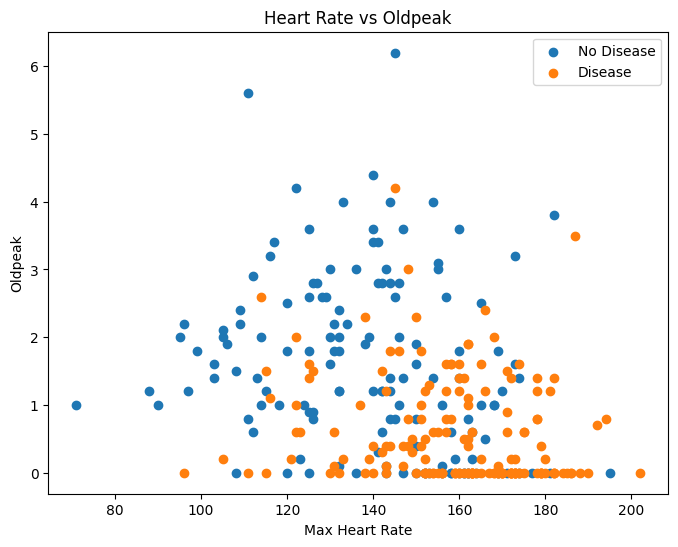

In [9]:
# Max Heart Rate vs Oldpeak
plt.figure(figsize=(8,6))

for t in np.unique(y):
    plt.scatter(df[df['target']==t]['thalach'],
                df[df['target']==t]['oldpeak'],
                label=target_names[t])

plt.xlabel("Max Heart Rate")
plt.ylabel("Oldpeak")
plt.title("Heart Rate vs Oldpeak")
plt.legend()
plt.show()

In [10]:
# ------------------------------
# 4. Split Dataset & Train Decision Tree
# ------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Initialize Decision Tree
dtree = DecisionTreeClassifier(criterion='entropy', random_state=42)

# Train model
dtree.fit(X_train, y_train)

# Predictions
y_pred = dtree.predict(X_test)

print("Predicted values:\n", y_pred)

Predicted values:
 [0 1 1 0 1 1 0 0 0 0 1 0 1 0 1 1 1 0 0 0 1 0 1 0 0 0 1 1 1 1 0 0 0 0 1 1 0
 1 0 1 1 1 1 0 0 0 1 1 0 0 0 0 1 1 0 0 1 1 0 0 0 1 0 1 1 0 0 1 1 1 1 1 1 1
 1 1 1 0 0 0 1 0 1 1 0 0 0 0 1 0 1]


Accuracy: 0.6923076923076923


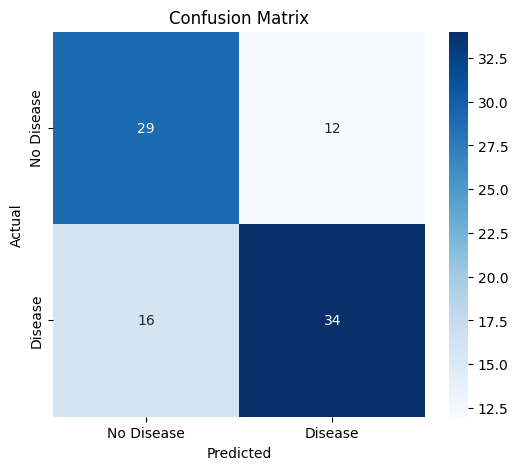

In [15]:
# ------------------------------
# 5. Model Evaluation
# ------------------------------

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


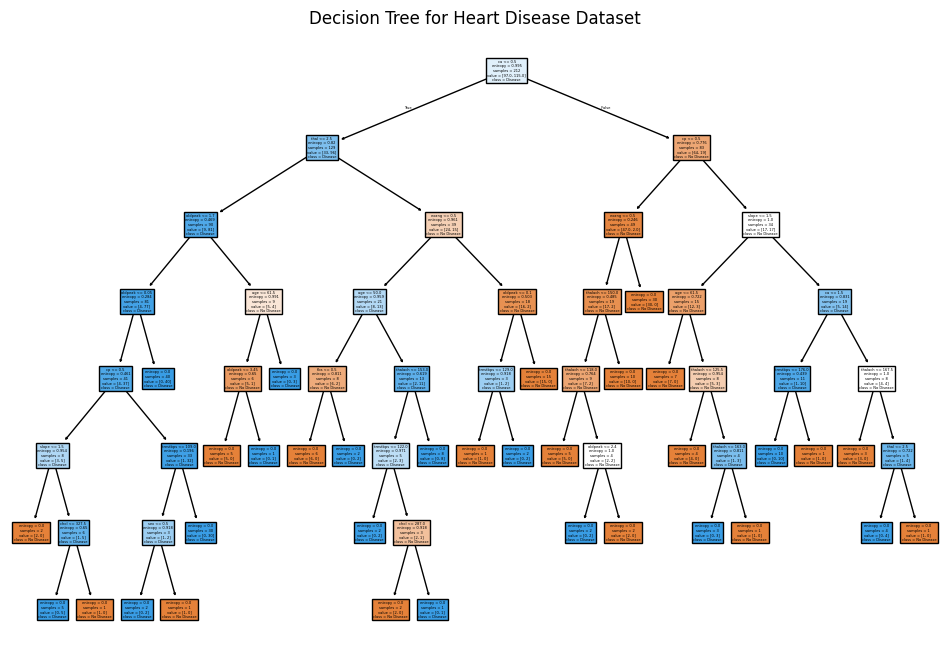

In [16]:
# ------------------------------
# 6. Decision Tree Visualization
# ------------------------------

plt.figure(figsize=(12,8))

plot_tree(
    dtree,
    feature_names=feature_names,
    class_names=target_names,
    filled=True
)

plt.title("Decision Tree for Heart Disease Dataset")
plt.show()

In [17]:
# ------------------------------
# 7. Predict New Sample
# ------------------------------

# Example patient data
new_sample = np.array([[63,1,3,145,233,1,0,150,0,2.3,0,0,1]])

prediction = dtree.predict(new_sample)

print("Predicted Result:", target_names[prediction[0]])

Predicted Result: Disease


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
